# 01 — CNN Training — ResNet-50 (CRC Histology)

Training **ResNet-50** (CNN baseline) on colorectal cancer histology tiles:
- **Train/Val**: NCT-CRC-HE-100K (stratified split)
- **Test**: CRC-VAL-HE-7K (external test set)

**Classes (9):** ADI, BACK, DEB, LYM, MUC, MUS, NORM, STR, TUM

**Role in thesis:** ResNet-50 = unique CNN baseline (contrôle positif) to compare with the 4 ViTs.

**Environment:** Kaggle (GPU T4 / P100)

## 0. Kaggle Setup — Clone repo & install deps

In [1]:
# Run once — remove old version if exists
!rm -rf /kaggle/working/xai-vit-medical
!git clone https://github.com/youssef-nouiouar/xai-vit-medical.git /kaggle/working/xai-vit-medical

Cloning into '/kaggle/working/xai-vit-medical'...
remote: Enumerating objects: 176, done.
remote: Counting objects: 100% (176/176), done.
remote: Compressing objects: 100% (121/121), done.
remote: Total 176 (delta 73), reused 143 (delta 48), pack-reused 0 (from 0)
Receiving objects: 100% (176/176), 967.49 KiB | 8.72 MiB/s, done.
Resolving deltas: 100% (73/73), done.


In [3]:
!pip install -q timm albumentations loguru
!pip install -q PyDrive2
!pip install seaborn


In [4]:
# Google Drive authentication (to save checkpoints)
from pydrive2.auth import GoogleAuth
from pydrive2.drive import GoogleDrive
from google.colab import auth
from oauth2client.client import GoogleCredentials

auth.authenticate_user()
gauth = GoogleAuth()
gauth.credentials = GoogleCredentials.get_application_default()
drive = GoogleDrive(gauth)

## 0b. Dataset (Kaggle input)

This notebook expects the CRC histology datasets to be available as Kaggle inputs.
Set paths below to point to:
- NCT-CRC-HE-100K (folder-per-class)
- CRC-VAL-HE-7K (folder-per-class)

In [5]:
from __future__ import annotations

from pathlib import Path


def first_existing_dir(candidates: list[Path]) -> Path:
    for p in candidates:
        if p.exists() and p.is_dir():
            return p
    raise FileNotFoundError(
        "None of the candidate dataset directories exist:\n"
        + "\n".join([f"- {c}" for c in candidates])
    )


# ---- Update these if your Kaggle dataset names differ ----
trainval_candidates = [
    Path("/kaggle/input/datasets/youssefnouiouar1/colorectal-cancer-histology-nct-crc-he-100k-and-7k/NCT-CRC-HE-100K/NCT-CRC-HE-100K")]
test_candidates = [
    Path("/kaggle/input/datasets/youssefnouiouar1/colorectal-cancer-histology-nct-crc-he-100k-and-7k/CRC-VAL-HE-7K/CRC-VAL-HE-7K"),
]

TRAINVAL_ROOT = first_existing_dir(trainval_candidates)
TEST_ROOT = first_existing_dir(test_candidates)

print(f"Train/Val root: {TRAINVAL_ROOT}")
print(f"Test root     : {TEST_ROOT}")

Train/Val root: /kaggle/input/datasets/youssefnouiouar1/colorectal-cancer-histology-nct-crc-he-100k-and-7k/NCT-CRC-HE-100K/NCT-CRC-HE-100K
Test root     : /kaggle/input/datasets/youssefnouiouar1/colorectal-cancer-histology-nct-crc-he-100k-and-7k/CRC-VAL-HE-7K/CRC-VAL-HE-7K


## 2. Configuration

In [6]:
import os
import sys
from collections import Counter

import numpy as np
import matplotlib.pyplot as plt
from tqdm.notebook import tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader

import timm
from sklearn.metrics import classification_report, confusion_matrix

PROJECT_ROOT = "/kaggle/working/xai-vit-medical"
if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)

from src.data.crc_dataset import CRCHistologyDataset, CRCSplits, DEFAULT_CRC_CLASSES
from src.utils.seed import set_seed

SEED = 42
set_seed(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {DEVICE}")
if torch.cuda.is_available():
    print(f"  GPU  : {torch.cuda.get_device_name(0)}")
print("Dependencies loaded.")

Device: cuda
  GPU  : Tesla T4
Dependencies loaded.


## 1. Dataset & DataLoaders

We build:
- a **stratified** train/val split from NCT-CRC-HE-100K
- an **external** test set from CRC-VAL-HE-7K

Transforms are applied online via Albumentations.

In [7]:
# ---- Paths ----
SAVE_DIR = f"{PROJECT_ROOT}/outputs/models"
os.makedirs(SAVE_DIR, exist_ok=True)

# ---- Dataset ----
IMAGE_SIZE = 224
CLASS_NAMES = list(DEFAULT_CRC_CLASSES)
NUM_CLASSES = len(CLASS_NAMES)
VAL_RATIO = 0.25
NUM_WORKERS = 2

# ---- Training ----
BATCH_SIZE = 32
EPOCHS = 30
LR = 3e-4
WEIGHT_DECAY = 1e-4
PATIENCE = 10

print("CRC Configuration:")
print(f"  Image size   : {IMAGE_SIZE}×{IMAGE_SIZE}")
print(f"  Num classes  : {NUM_CLASSES}")
print(f"  Val ratio    : {VAL_RATIO}")
print(f"  Batch size   : {BATCH_SIZE}")
print(f"  Epochs       : {EPOCHS}")
print(f"  Patience     : {PATIENCE}")

CRC Configuration:
  Image size   : 224×224
  Num classes  : 9
  Val ratio    : 0.25
  Batch size   : 32
  Epochs       : 30
  Patience     : 10


In [8]:
from pathlib import Path


def count_images_by_class(root: Path, class_names: list[str]) -> dict[str, int]:
    counts: dict[str, int] = {}
    for cls in class_names:
        cls_dir = root / cls
        if not cls_dir.exists():
            counts[cls] = 0
            continue
        n = 0
        for ext in ("*.png", "*.jpg", "*.jpeg", "*.tif", "*.tiff"):
            n += len(list(cls_dir.glob(ext)))
        counts[cls] = n
    return counts


trainval_counts = count_images_by_class(TRAINVAL_ROOT, CLASS_NAMES)
test_counts = count_images_by_class(TEST_ROOT, CLASS_NAMES)

print("Train/Val counts (per class):")
for k, v in trainval_counts.items():
    print(f"  {k:5s}: {v}")

print("\nTest counts (per class):")
for k, v in test_counts.items():
    print(f"  {k:5s}: {v}")

Train/Val counts (per class):
  ADI  : 10407
  BACK : 10566
  DEB  : 11512
  LYM  : 11557
  MUC  : 8896
  MUS  : 13536
  NORM : 8763
  STR  : 10446
  TUM  : 14317

Test counts (per class):
  ADI  : 1338
  BACK : 847
  DEB  : 339
  LYM  : 634
  MUC  : 1035
  MUS  : 592
  NORM : 741
  STR  : 421
  TUM  : 1233


In [9]:
import albumentations as A
from albumentations.pytorch import ToTensorV2

# ---- Transforms ----
# Note: A.Normalize() uses max_pixel_value=255 by default, so pixels are implicitly scaled by /255
train_transform = A.Compose(
    [
        A.RandomResizedCrop(size=(IMAGE_SIZE, IMAGE_SIZE), scale=(0.8, 1.0), ratio=(0.9, 1.1), p=1.0),
        A.HorizontalFlip(p=0.5),
        A.VerticalFlip(p=0.5),
        A.RandomRotate90(p=0.5),
        A.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.05, p=0.5),
        A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
        ToTensorV2(),
    ]
 )
val_transform = A.Compose(
    [
        A.Resize(IMAGE_SIZE, IMAGE_SIZE),
        A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
        ToTensorV2(),
    ]
 )

print("Transforms ready.")

Transforms ready.


## 4. Model — ResNet-50

- Pré-entraîné ImageNet (transfer learning)
- Pas de dropout
- Tête de classification : FC → 9 classes

In [10]:
# ---- Build splits ----
crc_splits = CRCSplits(
    trainval_root=TRAINVAL_ROOT,
    test_root=TEST_ROOT,
    classes=tuple(CLASS_NAMES),
    val_ratio=VAL_RATIO,
    random_state=SEED,
 )

# ---- Datasets ----
train_dataset = CRCHistologyDataset(
    splits=crc_splits,
    split="train",
    image_size=IMAGE_SIZE,
    transform=train_transform,
 )
val_dataset = CRCHistologyDataset(
    splits=crc_splits,
    split="val",
    image_size=IMAGE_SIZE,
    transform=val_transform,
 )
test_dataset = CRCHistologyDataset(
    splits=crc_splits,
    split="test",
    image_size=IMAGE_SIZE,
    transform=val_transform,
 )

print(f"Train: {len(train_dataset)} | Val: {len(val_dataset)} | Test: {len(test_dataset)}")

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=True,
 )
val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=True,
 )
test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=True,
 )

2026-05-05 09:44:32.811 | INFO     | src.data.crc_dataset:__init__:162 - CRC dataset split=train: 75000 images (root=/kaggle/input/datasets/youssefnouiouar1/colorectal-cancer-histology-nct-crc-he-100k-and-7k/NCT-CRC-HE-100K/NCT-CRC-HE-100K)
2026-05-05 09:49:17.594 | INFO     | src.data.crc_dataset:__init__:162 - CRC dataset split=val: 25000 images (root=/kaggle/input/datasets/youssefnouiouar1/colorectal-cancer-histology-nct-crc-he-100k-and-7k/NCT-CRC-HE-100K/NCT-CRC-HE-100K)
2026-05-05 09:49:48.754 | INFO     | src.data.crc_dataset:__init__:162 - CRC dataset split=test: 7180 images (root=/kaggle/input/datasets/youssefnouiouar1/colorectal-cancer-histology-nct-crc-he-100k-and-7k/CRC-VAL-HE-7K/CRC-VAL-HE-7K)


Train: 75000 | Val: 25000 | Test: 7180


## 5. Training Loop

| Composant | Choix |
|-----------|-------|
| Loss | **CrossEntropyLoss** |
| Optimizer | Adam (lr=3e-4, wd=1e-4) |
| Scheduler | ReduceLROnPlateau (patience=5, factor=0.5) sur val_loss |
| Mixed Precision | torch.amp (FP16) |
| Early stopping | patience=10 sur val_acc |
| Epochs | 30 |

In [20]:
def train_one_epoch(
    model: nn.Module,
    loader: DataLoader,
    criterion: nn.Module,
    optimizer: optim.Optimizer,
    scaler: torch.amp.GradScaler,
    device: torch.device,
) -> tuple[float, float]:
    model.train()
    running_loss, correct, total = 0.0, 0, 0

    pbar = tqdm(loader, desc='  Train', leave=False)
    for images, labels in pbar:
        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        optimizer.zero_grad(set_to_none=True)
        with torch.amp.autocast(device_type=device.type, enabled=True):
            outputs = model(images)
            loss = criterion(outputs, labels)

        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        scaler.step(optimizer)
        scaler.update()

        running_loss += loss.item() * images.size(0)
        _, preds = outputs.max(1)
        correct += preds.eq(labels).sum().item()
        total   += labels.size(0)
        pbar.set_postfix(loss=f'{loss.item():.4f}', acc=f'{correct/total:.4f}')

    return running_loss / total, correct / total


@torch.no_grad()
def evaluate(
    model: nn.Module,
    loader: DataLoader,
    criterion: nn.Module,
    device: torch.device,
) -> tuple[float, float, np.ndarray, np.ndarray]:
    model.eval()
    running_loss, correct, total = 0.0, 0, 0
    all_preds, all_labels = [], []

    for images, labels in tqdm(loader, desc='  Eval ', leave=False):
        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        with torch.amp.autocast(device_type=device.type, enabled=True):
            outputs = model(images)
            loss = criterion(outputs, labels)

        running_loss += loss.item() * images.size(0)
        _, preds = outputs.max(1)
        correct += preds.eq(labels).sum().item()
        total   += labels.size(0)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

    return running_loss / total, correct / total, np.array(all_preds), np.array(all_labels)


def train_model(
    model: nn.Module,
    model_name: str,
    train_loader: DataLoader,
    val_loader: DataLoader,
    epochs: int = EPOCHS,
    lr: float = LR,
    weight_decay: float = WEIGHT_DECAY,
    patience: int = PATIENCE,
    device: torch.device = DEVICE,
) -> tuple[nn.Module, dict]:
    model = model.to(device)

    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode='min', factor=0.5, patience=5
    )
    scaler = torch.amp.GradScaler('cuda', enabled=(device.type == 'cuda'))

    best_val_acc = 0.0
    epochs_no_improve = 0
    history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': [], 'lr': []}
    save_path = os.path.join(SAVE_DIR, f'{model_name}_best.pth')

    n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print(f'\n{"="*60}')
    print(f'Training {model_name}  |  {epochs} epochs  |  lr={lr}  |  patience={patience}')
    print(f'Trainable params : {n_params:,}')
    print(f'{"="*60}\n')

    for epoch in range(1, epochs + 1):
        current_lr = optimizer.param_groups[0]['lr']
        print(f'Epoch {epoch}/{epochs}  (lr={current_lr:.2e})')

        train_loss, train_acc = train_one_epoch(
            model, train_loader, criterion, optimizer, scaler, device
        )
        val_loss, val_acc, _, _ = evaluate(model, val_loader, criterion, device)
        scheduler.step(val_loss)

        history['train_loss'].append(train_loss)
        history['train_acc'].append(train_acc)
        history['val_loss'].append(val_loss)
        history['val_acc'].append(val_acc)
        history['lr'].append(current_lr)

        tag = ''
        if val_acc > best_val_acc:
            best_val_acc = val_acc
            epochs_no_improve = 0
            torch.save({
                'epoch': epoch,
                'model_state_dict': model.state_dict(),
                'optimizer_state_dict': optimizer.state_dict(),
                'val_loss': val_loss,
                'val_acc': val_acc,
                'history': history,
                'class_names': CLASS_NAMES,
                'model_name': model_name,
            }, save_path)
            tag = ' ★'
        else:
            epochs_no_improve += 1

        print(f'  train_loss={train_loss:.4f}  train_acc={train_acc:.4f}')
        print(f'  val_loss  ={val_loss:.4f}  val_acc  ={val_acc:.4f}{tag}')

        if epochs_no_improve >= patience:
            print(f'\nEarly stopping at epoch {epoch} (no improvement for {patience} epochs)')
            break

    print(f'\nBest val_acc={best_val_acc:.4f} — checkpoint: {save_path}')
    return model, history

print('Training functions defined.')

Training functions defined.


## 6. Train ResNet-50

In [21]:
def build_resnet50(num_classes: int, pretrained: bool = True) -> nn.Module:
    model = timm.create_model('resnet50', pretrained=pretrained, num_classes=num_classes)
    return model

print(f"ResNet-50 ready — output head: FC → {NUM_CLASSES} classes")

ResNet-50 ready — output head: FC → 9 classes


In [22]:
resnet50 = build_resnet50(num_classes=NUM_CLASSES, pretrained=True)

resnet50, resnet50_history = train_model(
    model=resnet50,
    model_name='resnet50',
    train_loader=train_loader,
    val_loader=val_loader,
    epochs=EPOCHS,
    lr=LR,
    weight_decay=WEIGHT_DECAY,
    patience=PATIENCE,
    device=DEVICE,
)


Training resnet50  |  30 epochs  |  lr=0.0003  |  patience=10
Trainable params : 23,526,473

Epoch 1/30  (lr=3.00e-04)


  Train:   0%|          | 0/2344 [00:00<?, ?it/s]

  Eval :   0%|          | 0/782 [00:00<?, ?it/s]

  train_loss=0.2081  train_acc=0.9366
  val_loss  =0.0638  val_acc  =0.9804 ★
Epoch 2/30  (lr=3.00e-04)


  Train:   0%|          | 0/2344 [00:00<?, ?it/s]

...

  Eval :   0%|          | 0/782 [00:00<?, ?it/s]

  train_loss=0.0175  train_acc=0.9944
  val_loss  =0.0147  val_acc  =0.9959
Epoch 30/30  (lr=7.50e-05)


  Train:   0%|          | 0/2344 [00:00<?, ?it/s]

  Eval :   0%|          | 0/782 [00:00<?, ?it/s]

  train_loss=0.0165  train_acc=0.9948
  val_loss  =0.0142  val_acc  =0.9958

Best val_acc=0.9962 — checkpoint: /kaggle/working/xai-vit-medical/outputs/models/resnet50_best.pth


## 7. Evaluation & Results

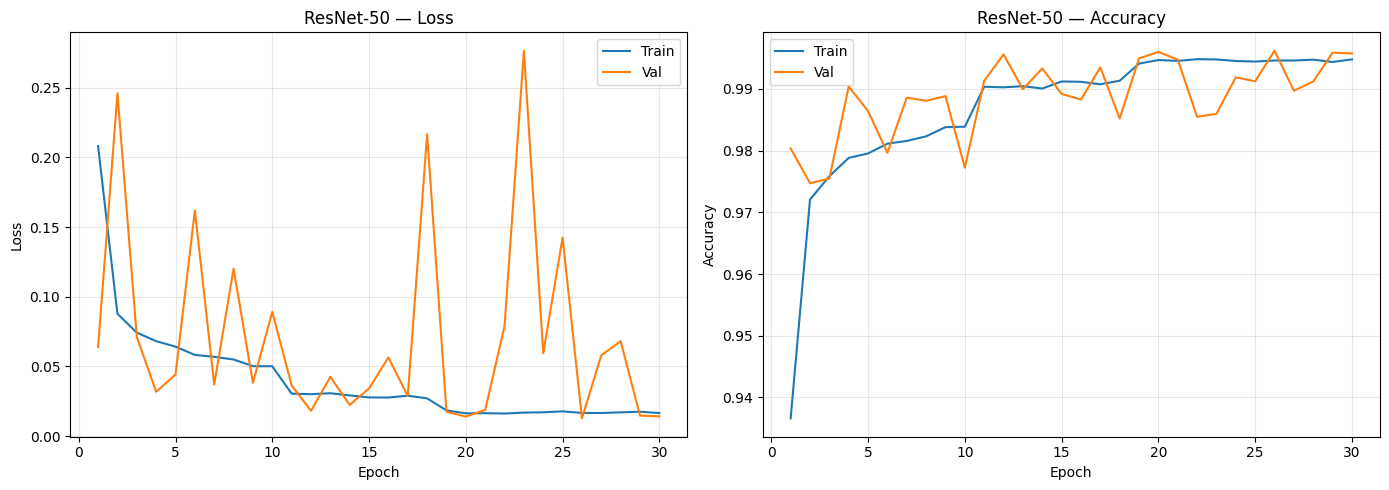

Saved: /kaggle/working/xai-vit-medical/outputs/models/ResNet-50_curves.png


In [23]:
import seaborn as sns
def plot_training_curves(history: dict, model_name: str) -> None:
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
    epochs_range = range(1, len(history['train_loss']) + 1)

    ax1.plot(epochs_range, history['train_loss'], label='Train')
    ax1.plot(epochs_range, history['val_loss'],   label='Val')
    ax1.set(xlabel='Epoch', ylabel='Loss', title=f'{model_name} — Loss')
    ax1.legend(); ax1.grid(alpha=0.3)

    ax2.plot(epochs_range, history['train_acc'], label='Train')
    ax2.plot(epochs_range, history['val_acc'],   label='Val')
    ax2.set(xlabel='Epoch', ylabel='Accuracy', title=f'{model_name} — Accuracy')
    ax2.legend(); ax2.grid(alpha=0.3)

    plt.tight_layout()
    out = os.path.join(SAVE_DIR, f'{model_name}_curves.png')
    plt.savefig(out, dpi=150)
    plt.show()
    print(f'Saved: {out}')


def evaluate_full(
    model: nn.Module,
    loader: DataLoader,
    model_name: str,
    split: str = 'val',
    device: torch.device = DEVICE,
) -> dict:
    criterion = nn.CrossEntropyLoss()
    loss, acc, preds, labels = evaluate(model, loader, criterion, device)
    print(f'\n{model_name} — {split.upper()} SET')
    print(f'  Loss     : {loss:.4f}')
    print(f'  Accuracy : {acc:.4f}  ({acc*100:.2f}%)')
    print(f'\n{classification_report(labels, preds, target_names=CLASS_NAMES, digits=4)}')

    cm = confusion_matrix(labels, preds)
    fig, ax = plt.subplots(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES, ax=ax)
    ax.set(xlabel='Predicted', ylabel='True',
           title=f'{model_name} — Confusion Matrix ({split})')
    plt.tight_layout()
    out = os.path.join(SAVE_DIR, f'{model_name}_cm_{split}.png')
    plt.savefig(out, dpi=150)
    plt.show()
    return {'loss': loss, 'acc': acc, 'preds': preds, 'labels': labels}


# ---- Courbes d'entraînement ----
plot_training_curves(resnet50_history, 'ResNet-50')

Best checkpoint: epoch 26  val_loss=0.0127  val_acc=0.9962


  Eval :   0%|          | 0/782 [00:00<?, ?it/s]


ResNet-50 — VAL SET
  Loss     : 0.0127
  Accuracy : 0.9962  (99.62%)

              precision    recall  f1-score   support

         ADI     0.9988    1.0000    0.9994      2602
        BACK     0.9996    1.0000    0.9998      2641
         DEB     0.9990    0.9958    0.9974      2878
         LYM     1.0000    0.9993    0.9997      2889
         MUC     0.9906    0.9973    0.9940      2224
         MUS     0.9938    0.9985    0.9962      3384
        NORM     0.9972    0.9904    0.9938      2191
         STR     0.9946    0.9843    0.9894      2612
         TUM     0.9928    0.9978    0.9953      3579

    accuracy                         0.9962     25000
   macro avg     0.9963    0.9959    0.9961     25000
weighted avg     0.9962    0.9962    0.9962     25000



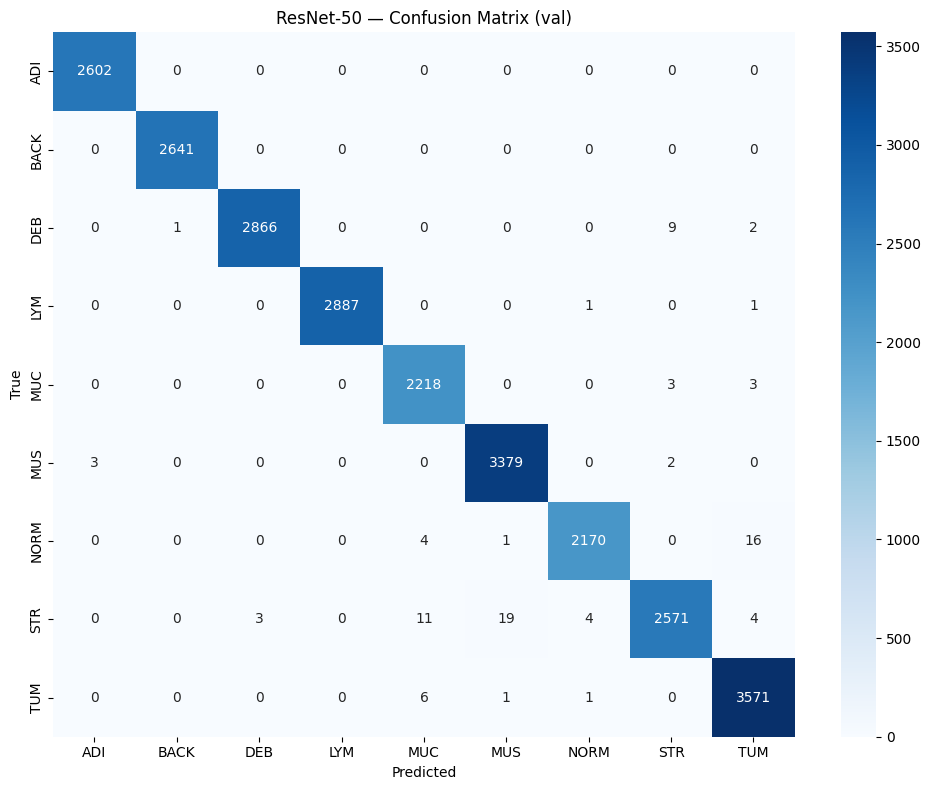

In [24]:
# ---- Évaluation sur val set ----
# Charger le meilleur checkpoint
ckpt = torch.load(os.path.join(SAVE_DIR, 'resnet50_best.pth'), map_location=DEVICE)
resnet50.load_state_dict(ckpt['model_state_dict'])
print(f"Best checkpoint: epoch {ckpt['epoch']}  val_loss={ckpt['val_loss']:.4f}  val_acc={ckpt['val_acc']:.4f}")

resnet50_val_results = evaluate_full(resnet50, val_loader, 'ResNet-50', split='val')

  Eval :   0%|          | 0/225 [00:00<?, ?it/s]


ResNet-50 — TEST SET
  Loss     : 0.1975
  Accuracy : 0.9476  (94.76%)

              precision    recall  f1-score   support

         ADI     0.9969    0.9499    0.9728      1338
        BACK     0.9988    1.0000    0.9994       847
         DEB     0.8805    1.0000    0.9365       339
         LYM     0.9844    0.9984    0.9914       634
         MUC     0.9841    0.9575    0.9706      1035
         MUS     0.7326    0.8699    0.7954       592
        NORM     0.9791    0.9501    0.9644       741
         STR     0.8645    0.6817    0.7623       421
         TUM     0.9598    0.9870    0.9732      1233

    accuracy                         0.9476      7180
   macro avg     0.9312    0.9327    0.9296      7180
weighted avg     0.9509    0.9476    0.9478      7180



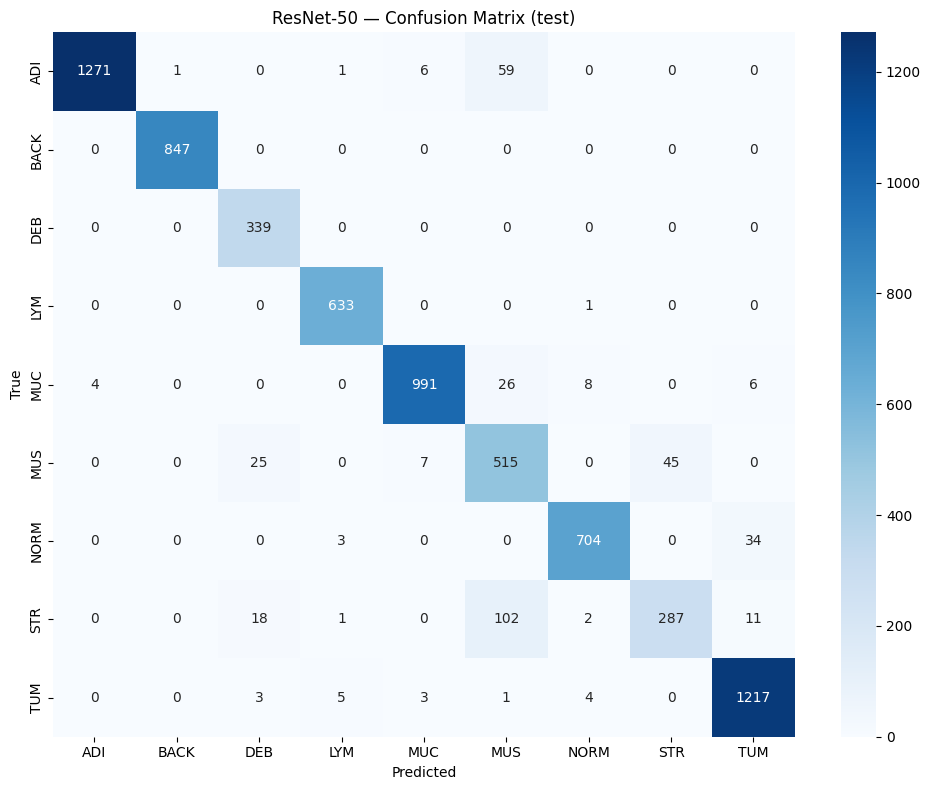

In [25]:
# ---- Évaluation sur test set officiel ----
resnet50_test_results = evaluate_full(resnet50, test_loader, 'ResNet-50', split='test')

## 8. Save Summary & Upload to Google Drive

In [27]:
import json
summary = {
    'resnet50': {
        'val_loss': float(resnet50_val_results['loss']),
        'val_acc':  float(resnet50_val_results['acc']),
        'test_loss': float(resnet50_test_results['loss']),
        'test_acc':  float(resnet50_test_results['acc']),
        'best_epoch': int(ckpt['epoch']),
        'epochs_trained': len(resnet50_history['train_loss']),
    }
}

summary_path = os.path.join(SAVE_DIR, 'cnn_training_summary.json')
with open(summary_path, 'w') as f:
    json.dump(summary, f, indent=2)

print('CNN Training Summary:')
print(f'  val_acc  = {summary["resnet50"]["val_acc"]:.4f}')
print(f'  test_acc = {summary["resnet50"]["test_acc"]:.4f}')
print(f'  best epoch = {summary["resnet50"]["best_epoch"]}')

CNN Training Summary:
  val_acc  = 0.9962
  test_acc = 0.9476
  best epoch = 26


In [28]:
# Upload checkpoint + summary to a specific Drive folder
SAVE_DIR  = '/kaggle/working/xai-vit-medical/outputs/models'
folder_id = "1eq-Jt6O6gO0Ck_oQYwmmc2qrCVLfKlec"   # <--- put your folder ID

files_to_upload = [
    'resnet50_best.pth',
    'cnn_training_summary.json',
    'ResNet-50_curves.png',
    'ResNet-50_cm_val.png',
    'ResNet-50_cm_test.png'
]

for fname in files_to_upload:
    fpath = os.path.join(SAVE_DIR, fname)

    if os.path.exists(fpath):
        drive_file = drive.CreateFile({
            'title': fname,
            'parents': [{'id': folder_id}]
        })

        drive_file.SetContentFile(fpath)
        drive_file.Upload()

        print(f"Uploaded: {fname}  (id={drive_file['id']})")
    else:
        print(f"Not found (skipped): {fname}")

print("\nDone. Files uploaded to folder.")


Uploaded: resnet50_best.pth  (id=1qJVxxMnAikkj9JHpLl6Ds-Ycq-zTvVM1)
Uploaded: cnn_training_summary.json  (id=1FxMZrxucefnFCFo-Zaz2qkLnJbnbB5Qf)
Uploaded: ResNet-50_curves.png  (id=1vkZNYnyUTnrOxfAv4KRX7dBf_djN1vM-)
Uploaded: ResNet-50_cm_val.png  (id=1hZalkHLG0j--9cVepznmgnW31yDCOt3w)
Uploaded: ResNet-50_cm_test.png  (id=1x6LULRRI52CknAZjNPArkMfTUu9CGxw3)

Done. Files uploaded to folder.
